# Packoscope

O projeto visa modelar um Intrusion Detection Sistem (IDS) a partir do dataset CIC-IDS-2017, gerado sinteticamente pelo Canadian Institute for Cybersecurity, Universidade de Brunswick, Canadá.

O dataset possui uso público para pesquisadores e seus detalhes e princípios podem ser lidos em detalhes no artigo: Iman Sharafaldin, Arash Habibi Lashkari, and Ali A. Ghorbani, “Toward Generating a New Intrusion Detection Dataset and Intrusion Traffic Characterization”, 4th International Conference on Information Systems Security and Privacy (ICISSP), Portugal, January 2018.

(WORK IN PROGRESS)

In [1]:
# imports necessários para o projeto

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# configs de estilo
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

In [3]:
# carregar dados

df = pd.read_parquet("data/pacotes.parquet")


## Dimensões da Base

In [4]:
df.shape

(2830743, 80)

Número de instâncias (linhas): 2.830.743
Número de atributos (colunas): 80

## Tipos de variáveis

In [5]:
# Informações gerais de tipo e consumo de memória
print("--- Resumo dos Tipos de Dados ---")
df.info()

# Contagem de valores únicos por coluna (ajuda a identificar chaves/IDs e categóricas)
print("\n--- Quantidade de Valores Únicos por Coluna ---")
unicos = df.nunique()
print(unicos)

# Separando colunas por tipos automaticamente
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
dt_cols = df.select_dtypes(include=['datetime64']).columns.tolist()

print("\nColunas Numéricas:", num_cols)
print("Colunas Categóricas:", cat_cols)
print("Colunas Temporais:", dt_cols)

--- Resumo dos Tipos de Dados ---
<class 'pandas.DataFrame'>
RangeIndex: 2830743 entries, 0 to 2830742
Data columns (total 80 columns):
 #   Column                       Dtype   
---  ------                       -----   
 0   Destination Port             int32   
 1   Flow Duration                int32   
 2   Total Fwd Packets            int32   
 3   Total Backward Packets       int32   
 4   Total Length of Fwd Packets  int32   
 5   Total Length of Bwd Packets  int32   
 6   Fwd Packet Length Max        int16   
 7   Fwd Packet Length Min        int16   
 8   Fwd Packet Length Mean       float32 
 9   Fwd Packet Length Std        float32 
 10  Bwd Packet Length Max        int16   
 11  Bwd Packet Length Min        int16   
 12  Bwd Packet Length Mean       float32 
 13  Bwd Packet Length Std        float32 
 14  Flow Bytes/s                 float32 
 15  Flow Packets/s               float32 
 16  Flow IAT Mean                float32 
 17  Flow IAT Std                 float32 
 18 

Destination Port                 53805
Flow Duration                  1050899
Total Fwd Packets                 1432
Total Backward Packets            1747
Total Length of Fwd Packets      17928
                                ...   
Idle Std                        196816
Idle Max                        149737
Idle Min                        223888
Label                               15
source_file                          8
Length: 80, dtype: int64

Colunas Numéricas: ['Fwd Header Length', 'Fwd Header Length.1']
Colunas Categóricas: ['Label', 'source_file']
Colunas Temporais: []


### Classificação dos Atributos

| Atributo | dtype | Classificação |
|---|---|---|
| `Destination Port` | `int32` | Categórica nominal |
| `Flow Duration` | `int32` | Numérica contínua |
| `Total Fwd Packets` | `int32` | Numérica discreta |
| `Total Backward Packets` | `int32` | Numérica discreta |
| `Total Length of Fwd Packets` | `int32` | Numérica discreta |
| `Total Length of Bwd Packets` | `int32` | Numérica discreta |
| `Fwd Packet Length Max` | `int16` | Numérica discreta |
| `Fwd Packet Length Min` | `int16` | Numérica discreta |
| `Fwd Packet Length Mean` | `float32` | Numérica contínua |
| `Fwd Packet Length Std` | `float32` | Numérica contínua |
| `Bwd Packet Length Max` | `int16` | Numérica discreta |
| `Bwd Packet Length Min` | `int16` | Numérica discreta |
| `Bwd Packet Length Mean` | `float32` | Numérica contínua |
| `Bwd Packet Length Std` | `float32` | Numérica contínua |
| `Flow Bytes/s` | `float32` | Numérica contínua |
| `Flow Packets/s` | `float32` | Numérica contínua |
| `Flow IAT Mean` | `float32` | Numérica contínua |
| `Flow IAT Std` | `float32` | Numérica contínua |
| `Flow IAT Max` | `int32` | Numérica contínua |
| `Flow IAT Min` | `int32` | Numérica contínua |
| `Fwd IAT Total` | `int32` | Numérica contínua |
| `Fwd IAT Mean` | `float32` | Numérica contínua |
| `Fwd IAT Std` | `float32` | Numérica contínua |
| `Fwd IAT Max` | `int32` | Numérica contínua |
| `Fwd IAT Min` | `int32` | Numérica contínua |
| `Bwd IAT Total` | `int32` | Numérica contínua |
| `Bwd IAT Mean` | `float32` | Numérica contínua |
| `Bwd IAT Std` | `float32` | Numérica contínua |
| `Bwd IAT Max` | `int32` | Numérica contínua |
| `Bwd IAT Min` | `int32` | Numérica contínua |
| `Fwd PSH Flags` | `int8` | Categórica nominal (binária) |
| `Bwd PSH Flags` | `int8` | Categórica nominal (binária) |
| `Fwd URG Flags` | `int8` | Categórica nominal (binária) |
| `Bwd URG Flags` | `int8` | Categórica nominal (binária) |
| `Fwd Header Length` | `int64` | Numérica discreta |
| `Bwd Header Length` | `int32` | Numérica discreta |
| `Fwd Packets/s` | `float32` | Numérica contínua |
| `Bwd Packets/s` | `float32` | Numérica contínua |
| `Min Packet Length` | `int16` | Numérica discreta |
| `Max Packet Length` | `int16` | Numérica discreta |
| `Packet Length Mean` | `float32` | Numérica contínua |
| `Packet Length Std` | `float32` | Numérica contínua |
| `Packet Length Variance` | `float32` | Numérica contínua |
| `FIN Flag Count` | `int8` | Categórica nominal (binária) |
| `SYN Flag Count` | `int8` | Categórica nominal (binária) |
| `RST Flag Count` | `int8` | Categórica nominal (binária) |
| `PSH Flag Count` | `int8` | Categórica nominal (binária) |
| `ACK Flag Count` | `int8` | Categórica nominal (binária) |
| `URG Flag Count` | `int8` | Categórica nominal (binária) |
| `CWE Flag Count` | `int8` | Categórica nominal (binária) |
| `ECE Flag Count` | `int8` | Categórica nominal (binária) |
| `Down/Up Ratio` | `int16` | Numérica discreta |
| `Average Packet Size` | `float32` | Numérica contínua |
| `Avg Fwd Segment Size` | `float32` | Numérica contínua |
| `Avg Bwd Segment Size` | `float32` | Numérica contínua |
| `Fwd Header Length.1` | `int64` | Numérica discreta |
| `Fwd Avg Bytes/Bulk` | `int8` | Numérica discreta |
| `Fwd Avg Packets/Bulk` | `int8` | Numérica discreta |
| `Fwd Avg Bulk Rate` | `int8` | Numérica discreta |
| `Bwd Avg Bytes/Bulk` | `int8` | Numérica discreta |
| `Bwd Avg Packets/Bulk` | `int8` | Numérica discreta |
| `Bwd Avg Bulk Rate` | `int8` | Numérica discreta |
| `Subflow Fwd Packets` | `int32` | Numérica discreta |
| `Subflow Fwd Bytes` | `int32` | Numérica discreta |
| `Subflow Bwd Packets` | `int32` | Numérica discreta |
| `Subflow Bwd Bytes` | `int32` | Numérica discreta |
| `Init_Win_bytes_forward` | `int32` | Numérica discreta |
| `Init_Win_bytes_backward` | `int32` | Numérica discreta |
| `act_data_pkt_fwd` | `int32` | Numérica discreta |
| `min_seg_size_forward` | `int32` | Numérica discreta |
| `Active Mean` | `float32` | Numérica contínua |
| `Active Std` | `float32` | Numérica contínua |
| `Active Max` | `int32` | Numérica contínua |
| `Active Min` | `int32` | Numérica contínua |
| `Idle Mean` | `float32` | Numérica contínua |
| `Idle Std` | `float32` | Numérica contínua |
| `Idle Max` | `int32` | Numérica contínua |
| `Idle Min` | `int32` | Numérica contínua |
| `Label` | `category` | Categórica nominal (alvo) |
| `source_file` | `category` | Categórica nominal (metadado) |

## Análise Exploratória

### Estatísticas Descritivas

In [6]:
# Label e source_file sao category e ficam de fora do select_dtypes

numericas = df.select_dtypes(include="number").columns
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

# percentis extras (1%, 5%, 95%, 99%) alem dos quartis padrao, pra ver a cauda
percentis = [0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]

desc = df[numericas].describe(percentiles=percentis).T
desc["skew"] = df[numericas].skew()

desc.sort_values("skew", ascending=False)

/home/vini/Dev/UFPE/projeto-ml/packoscope/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/home/vini/Dev/UFPE/projeto-ml/packoscope/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1028: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


/home/vini/Dev/UFPE/projeto-ml/packoscope/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1275: RuntimeWarning: invalid value encountered in subtract
  adjusted = values - mean


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max,skew
Total Length of Fwd Packets,"2,830,743.00",549.30,"9,993.59",0.00,0.00,0.00,12.00,62.00,187.00,"1,775.00","11,595.00","12,900,000.00",805.57
Subflow Fwd Bytes,"2,830,743.00",549.29,"9,980.07",0.00,0.00,0.00,12.00,62.00,187.00,"1,775.00","11,595.00","12,870,338.00",803.60
act_data_pkt_fwd,"2,830,743.00",5.42,636.43,0.00,0.00,0.00,0.00,1.00,2.00,11.00,27.00,"213,557.00",284.60
Total Backward Packets,"2,830,743.00",10.39,997.39,0.00,0.00,0.00,1.00,2.00,4.00,17.00,57.00,"291,922.00",244.68
Subflow Bwd Packets,"2,830,743.00",10.39,997.39,0.00,0.00,0.00,1.00,2.00,4.00,17.00,57.00,"291,922.00",244.68
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Bwd Header Length,"2,830,743.00","-2,273.28","1,452,208.94","-1,073,741,320.00",0.00,0.00,20.00,40.00,104.00,488.00,"1,520.00","5,838,440.00",-717.03
Fwd Header Length,"2,830,743.00","-25,997.39","21,052,857.87","-32,212,234,632.00",20.00,20.00,40.00,64.00,120.00,492.00,"1,328.00","4,644,908.00","-1,325.07"
Fwd Header Length.1,"2,830,743.00","-25,997.39","21,052,857.87","-32,212,234,632.00",20.00,20.00,40.00,64.00,120.00,492.00,"1,328.00","4,644,908.00","-1,325.07"
Flow Bytes/s,"2,829,385.00",inf,NaN,"-261,000,000.00",0.00,0.00,119.32,"4,595.55","166,666.67","2,270,270.25","12,333,333.00",inf,NaN


In [7]:
contagem_labels = df["Label"].value_counts()

contagem_labels

Label
BENIGN                        2273097
DoS Hulk                       231073
PortScan                       158930
DDoS                           128027
DoS GoldenEye                   10293
FTP-Patator                      7938
SSH-Patator                      5897
DoS slowloris                    5796
DoS Slowhttptest                 5499
Bot                              1966
Web Attack - Brute Force         1507
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64

In [8]:
# porcentagem das classes
percentual_labels = (
    df["Label"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

percentual_labels

Label
BENIGN                       80.30
DoS Hulk                      8.16
PortScan                      5.61
DDoS                          4.52
DoS GoldenEye                 0.36
FTP-Patator                   0.28
SSH-Patator                   0.21
DoS slowloris                 0.20
DoS Slowhttptest              0.19
Bot                           0.07
Web Attack - Brute Force      0.05
Web Attack - XSS              0.02
Infiltration                  0.00
Web Attack - Sql Injection    0.00
Heartbleed                    0.00
Name: proportion, dtype: float64

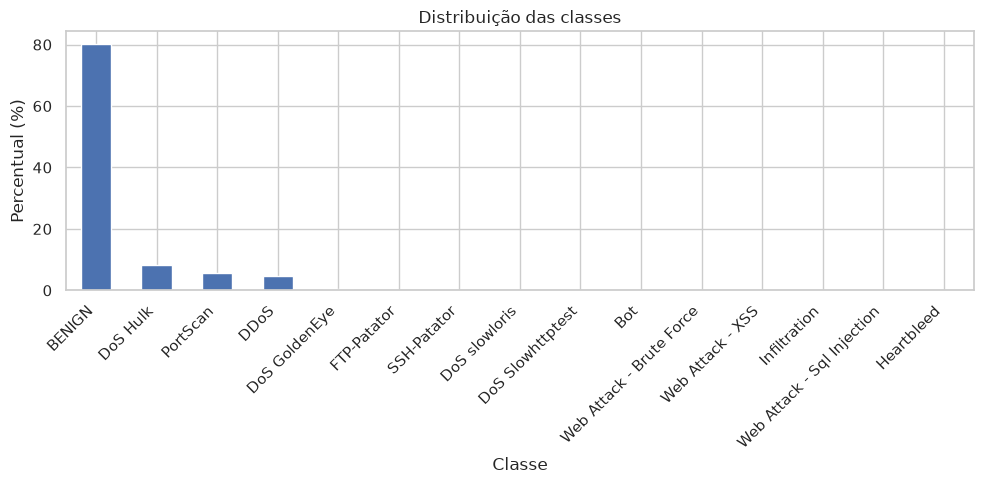

In [9]:
#melhor visualização da distribuição das classes
ax = percentual_labels.sort_values(ascending=False).plot(kind="bar")

ax.set_title("Distribuição das classes")
ax.set_xlabel("Classe")
ax.set_ylabel("Percentual (%)")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Distribuições Numéricas

Foram gerados histogramas de duas variáveis já identificadas com cauda pesada nas seções anteriores, com escala logarítmica no eixo de contagem.

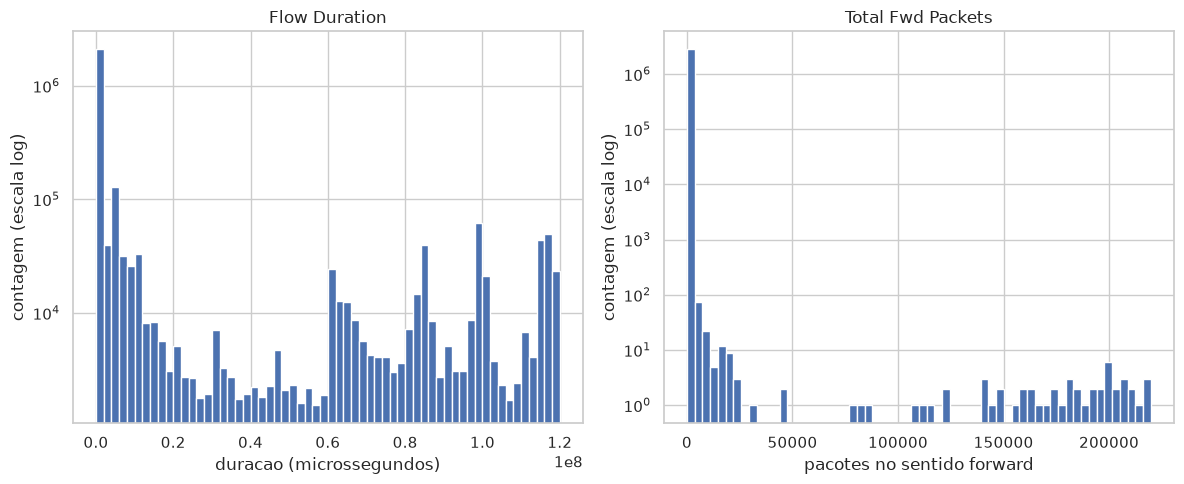

In [10]:
# escala log no eixo y por causa da cauda 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df["Flow Duration"].plot.hist(bins=60, log=True, ax=axes[0])
axes[0].set_title("Flow Duration")
axes[0].set_xlabel("duracao (microssegundos)")
axes[0].set_ylabel("contagem (escala log)")

df["Total Fwd Packets"].plot.hist(bins=60, log=True, ax=axes[1])
axes[1].set_title("Total Fwd Packets")
axes[1].set_xlabel("pacotes no sentido forward")
axes[1].set_ylabel("contagem (escala log)")

plt.tight_layout()
plt.show()

### Boxplot por Classe

Para comparar `Flow Duration` entre tráfego benigno e malicioso, o rótulo foi colapsado em binário apenas para esta visualização (sem alterar a base). Os outliers foram ocultados para não esmagar a caixa, eles são investigados na seção de outliers e não estão sendo descartados.

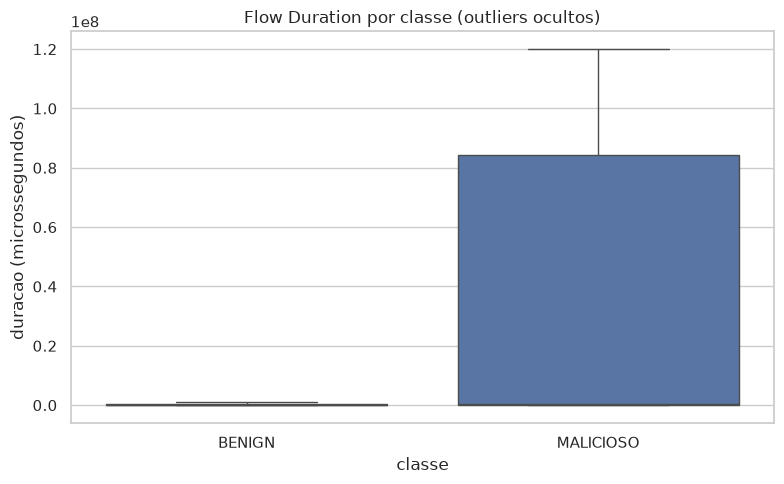

In [11]:
alvo_binario = np.where(df["Label"] == "BENIGN", "BENIGN", "MALICIOSO")

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(x=alvo_binario, y=df["Flow Duration"], showfliers=False, ax=ax)
ax.set_title("Flow Duration por classe (outliers ocultos)")
ax.set_xlabel("classe")
ax.set_ylabel("duracao (microssegundos)")
plt.tight_layout()
plt.show()

### Correlação entre Atributos

Foi calculada a matriz de correlação de Pearson sobre as colunas numéricas, e extraído o ranking dos pares mais correlacionados (ordenado por valor absoluto, ignorando a diagonal e os pares repetidos por simetria). Um heatmap com todas as colunas seria ilegível, então reduzimos às colunas que aparecem no ranking.

In [12]:
numericas = df.select_dtypes(include="number").columns
corr = df[numericas].corr()

pares = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .abs()
    .sort_values(ascending=False)
)

pares.head(15)

Total Backward Packets       Subflow Bwd Packets      1.00
Fwd PSH Flags                SYN Flag Count           1.00
Fwd Packet Length Mean       Avg Fwd Segment Size     1.00
Fwd URG Flags                CWE Flag Count           1.00
Fwd Header Length            Fwd Header Length.1      1.00
Total Fwd Packets            Subflow Fwd Packets      1.00
Bwd Packet Length Mean       Avg Bwd Segment Size     1.00
Total Length of Bwd Packets  Subflow Bwd Bytes        1.00
Total Length of Fwd Packets  Subflow Fwd Bytes        1.00
Total Fwd Packets            Subflow Bwd Packets      1.00
                             Total Backward Packets   1.00
Subflow Fwd Packets          Subflow Bwd Packets      1.00
Total Backward Packets       Subflow Fwd Packets      1.00
Flow Duration                Fwd IAT Total            1.00
Flow IAT Max                 Fwd IAT Max              1.00
dtype: float64

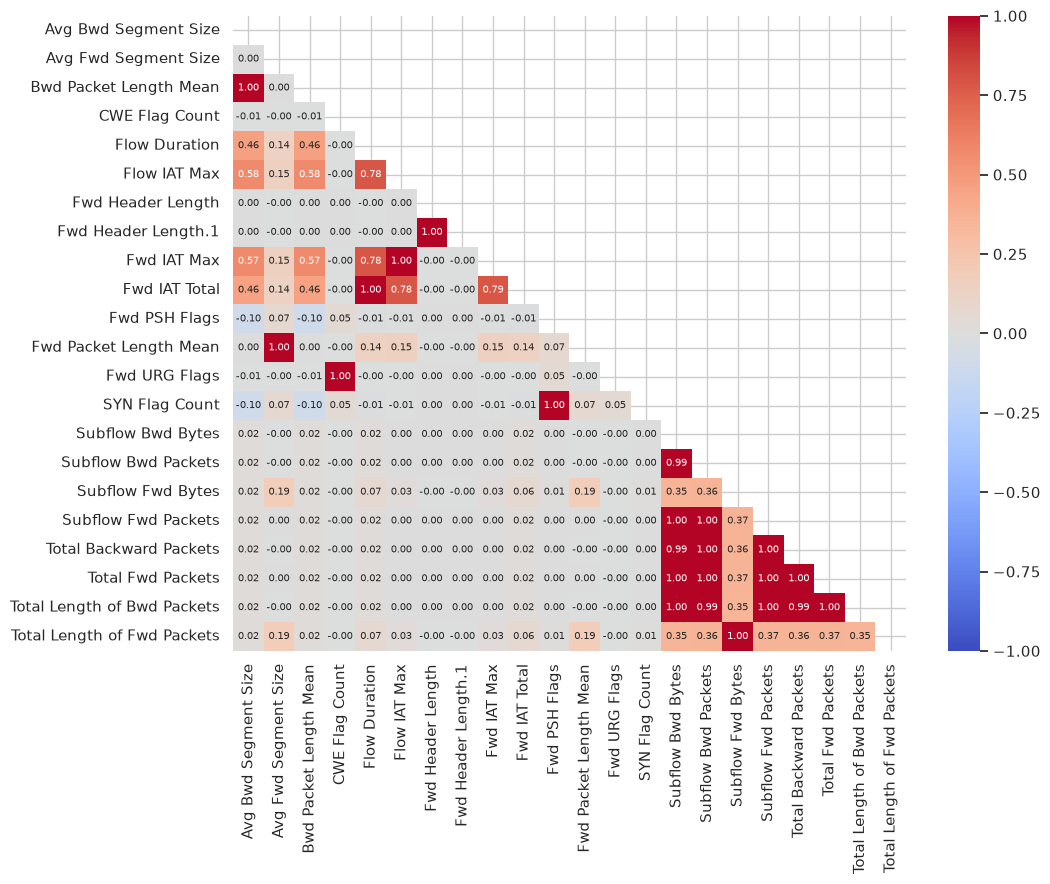

In [13]:
# heatmap so com as colunas que aparecem no top 15 do ranking acima
colunas_heatmap = sorted(
    set(pares.head(15).index.get_level_values(0))
    | set(pares.head(15).index.get_level_values(1))
)

mask = np.triu(np.ones((len(colunas_heatmap), len(colunas_heatmap))), k=1).astype(bool)

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr.loc[colunas_heatmap, colunas_heatmap],
    mask=~mask.T,
    cmap="coolwarm", center=0, vmin=-1, vmax=1,
    annot=True, fmt=".2f", annot_kws={"size": 7},
    ax=ax,
)
plt.tight_layout()
plt.show()

### Dispersão entre Atributos

Para visualizar o par mais correlacionado do ranking (r = 1,0), foi criado um gráfico de dispersão entre `Fwd Header Length` e `Fwd Header Length.1`, com uma amostra de 20 mil linhas, já que a base inteira produziria apenas uma mancha.

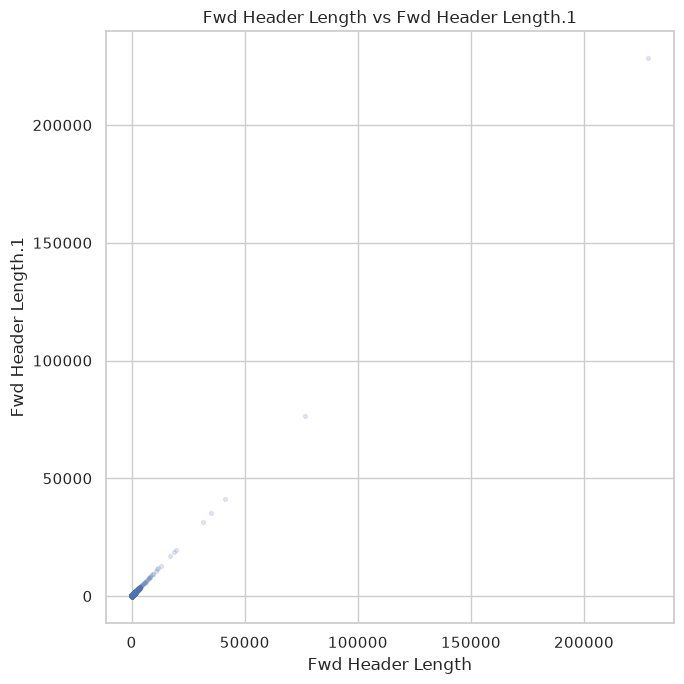

In [14]:
# amostra por causa de 2.8m de linhas, senao o scatter so vira uma mancha
amostra = df[["Fwd Header Length", "Fwd Header Length.1"]].sample(n=20000, random_state=42)

fig, ax = plt.subplots(figsize=(7, 7))
ax.scatter(amostra["Fwd Header Length"], amostra["Fwd Header Length.1"], alpha=0.15, s=8)
ax.set_title("Fwd Header Length vs Fwd Header Length.1")
ax.set_xlabel("Fwd Header Length")
ax.set_ylabel("Fwd Header Length.1")
plt.tight_layout()
plt.show()

### Duplicatas Exatas entre Atributos

Uma correlação próxima de 1 não garante que duas colunas sejam iguais. Por isso, para cada par com correlação acima de 0,9999 no ranking, foi conferido linha a linha se os valores são idênticos.

In [15]:
# pares com correlacao ~1: sao duplicatas de verdade ou so muito parecidos?
candidatos = pares[pares > 0.9999]

linhas = []
for (a, b), r in candidatos.items():
    x, y_ = df[a].astype("float64"), df[b].astype("float64")
    dif = (x != y_) & ~(x.isna() & y_.isna())  # nan nos dois lados conta como igual
    linhas.append({
        "atributo_1": a, "atributo_2": b, "correlacao": f"{r:.6f}",
        "identicas": int(dif.sum()) == 0, "linhas_diferentes": int(dif.sum()),
    })

duplicatas = pd.DataFrame(linhas).sort_values("linhas_diferentes")
print(f"pares com correlacao > 0.9999: {len(duplicatas)} | identicos linha a linha: {int(duplicatas['identicas'].sum())}")

duplicatas

pares com correlacao > 0.9999: 9 | identicos linha a linha: 7


,atributo_1,atributo_2,correlacao,identicas,linhas_diferentes
0,Total Backward Packets,Subflow Bwd Packets,1.000000,True,0
1,Fwd PSH Flags,SYN Flag Count,1.000000,True,0
2,Fwd Packet Length Mean,Avg Fwd Segment Size,1.000000,True,0
3,Fwd URG Flags,CWE Flag Count,1.000000,True,0
4,Fwd Header Length,Fwd Header Length.1,1.000000,True,0
5,Total Fwd Packets,Subflow Fwd Packets,1.000000,True,0
6,Bwd Packet Length Mean,Avg Bwd Segment Size,1.000000,True,0
8,Total Length of Fwd Packets,Subflow Fwd Bytes,0.999999,False,1
7,Total Length of Bwd Packets,Subflow Bwd Bytes,1.000000,False,146


Dos 9 pares com correlação acima de 0,9999, 7 são colunas idênticas linha a linha e 2 são quase idênticas: `Total Length of Bwd Packets` e `Subflow Bwd Bytes` (146 linhas diferentes, 0,005% da base) e `Total Length of Fwd Packets` e `Subflow Fwd Bytes` (1 linha diferente). Portanto, uma coluna de cada par é candidata à remoção. Dois dos pares idênticos ligam flags com nomes distintos (`Fwd PSH Flags` e `SYN Flag Count`, `Fwd URG Flags` e `CWE Flag Count`), o que pode indicar um problema na extração das *features*.

### Vazamento por Origem (`source_file` × `Label`)

`source_file` é um metadado e não deve ser usada como *feature*. Mesmo assim, medimos o quanto ela revela do rótulo, já que cada dia de captura tende a concentrar um tipo específico de tráfego.

In [16]:
# contagem bruta: em quais arquivos cada classe aparece
ct = pd.crosstab(df["source_file"], df["Label"])
ct

Label,BENIGN,Bot,DDoS,DoS GoldenEye,DoS Hulk,DoS Slowhttptest,DoS slowloris,FTP-Patator,Heartbleed,Infiltration,PortScan,SSH-Patator,Web Attack - Brute Force,Web Attack - Sql Injection,Web Attack - XSS
source_file,,,,,,,,,,,,,,,
Friday-WorkingHours-Afternoon-DDos.pcap_ISCX,97718,0,128027,0,0,0,0,0,0,0,0,0,0,0,0
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX,127537,0,0,0,0,0,0,0,0,0,158930,0,0,0,0
Friday-WorkingHours-Morning.pcap_ISCX,189067,1966,0,0,0,0,0,0,0,0,0,0,0,0,0
Monday-WorkingHours.pcap_ISCX,529918,0,0,0,0,0,0,0,0,0,0,0,0,0,0
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX,288566,0,0,0,0,0,0,0,0,36,0,0,0,0,0
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX,168186,0,0,0,0,0,0,0,0,0,0,0,1507,21,652
Tuesday-WorkingHours.pcap_ISCX,432074,0,0,0,0,0,0,7938,0,0,0,5897,0,0,0
Wednesday-workingHours.pcap_ISCX,440031,0,0,10293,231073,5499,5796,0,11,0,0,0,0,0,0


In [17]:
# em quantos arquivos distintos cada classe aparece
arquivos_por_classe = (ct > 0).sum(axis=0).sort_values()
n_exclusivas = (arquivos_por_classe == 1).sum()

print(arquivos_por_classe)
print()
print(f"classes exclusivas de um unico arquivo: {n_exclusivas} de {len(arquivos_por_classe)}")

Label
Bot                           1
DDoS                          1
DoS GoldenEye                 1
DoS Hulk                      1
DoS slowloris                 1
DoS Slowhttptest              1
FTP-Patator                   1
Heartbleed                    1
Web Attack - Brute Force      1
Infiltration                  1
PortScan                      1
SSH-Patator                   1
Web Attack - XSS              1
Web Attack - Sql Injection    1
BENIGN                        8
dtype: int64

classes exclusivas de um unico arquivo: 14 de 15


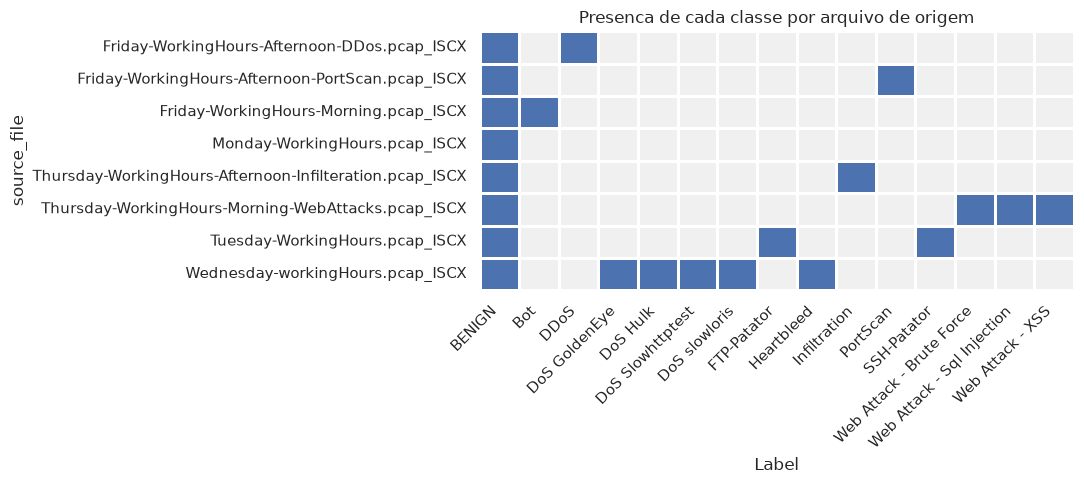

In [18]:
# heatmap de presenca: 1 se a classe aparece no arquivo, 0 se nao
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(
    (ct > 0).astype(int),
    cmap=["#f0f0f0", "#4c72b0"], cbar=False,
    linewidths=1, linecolor="white", ax=ax,
)
ax.set_title("Presenca de cada classe por arquivo de origem")
ax.set_xlabel("Label")
ax.set_ylabel("source_file")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

14 das 15 classes aparecem em um único arquivo de origem, ou seja, só `BENIGN` está presente em todos os 8. Dessa forma, saber de qual arquivo (dia) uma linha veio já restringe bastante o tipo de ataque possível, por isso `source_file` fica de fora do conjunto de *features*: usá-la faria o modelo aprender o calendário da coleta e não o comportamento do tráfego.

### Correlação com o Alvo

Foram calculadas as correlações de cada atributo numérico com o rótulo binarizado (malicioso = 1), por dois métodos: Pearson, que contra um alvo 0/1 equivale ao coeficiente ponto-bisserial, e Spearman, que correlaciona os postos e é menos sensível às caudas pesadas. O `inf` foi tratado como `NaN` apenas dentro deste cálculo (o `df` não é alterado), as 8 colunas constantes ficam sem correlação definida e `Destination Port` foi excluída, por ser nominal.

In [19]:
# alvo binario so pra esse calculo, sem alterar o df
y_malicioso = (df["Label"] != "BENIGN").astype("int8")

# inf vira nan so aqui, corrwith descarta pares com nan
X = df[numericas].replace([np.inf, -np.inf], np.nan)

corr_alvo = pd.DataFrame({
    "pearson": X.corrwith(y_malicioso),
    "spearman": X.corrwith(y_malicioso, method="spearman"),
})

# constantes ficam nan nos dois metodos; port e nominal, correlacao nao faz sentido
print("constantes (sem correlacao definida):", int(corr_alvo.isna().all(axis=1).sum()))
corr_alvo = corr_alvo.dropna(how="all").drop(index="Destination Port")

corr_alvo = corr_alvo.reindex(corr_alvo["spearman"].abs().sort_values(ascending=False).index)
print("atributos no ranking:", len(corr_alvo))

corr_alvo.head(15)

/home/vini/Dev/UFPE/projeto-ml/packoscope/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/vini/Dev/UFPE/projeto-ml/packoscope/.venv/lib/python3.11/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


/home/vini/Dev/UFPE/projeto-ml/packoscope/.venv/lib/python3.11/site-packages/pandas/core/nanops.py:1673: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


constantes (sem correlacao definida): 8
atributos no ranking: 69


,pearson,spearman
Min Packet Length,-0.30,-0.36
Fwd Packet Length Min,-0.14,-0.35
Bwd Packet Length Min,-0.28,-0.28
Bwd Packet Length Std,0.51,0.28
Idle Max,0.39,0.25
Fwd IAT Std,0.42,0.25
Idle Mean,0.39,0.25
Idle Min,0.38,0.25
Init_Win_bytes_forward,0.01,0.24
Avg Fwd Segment Size,-0.09,-0.22


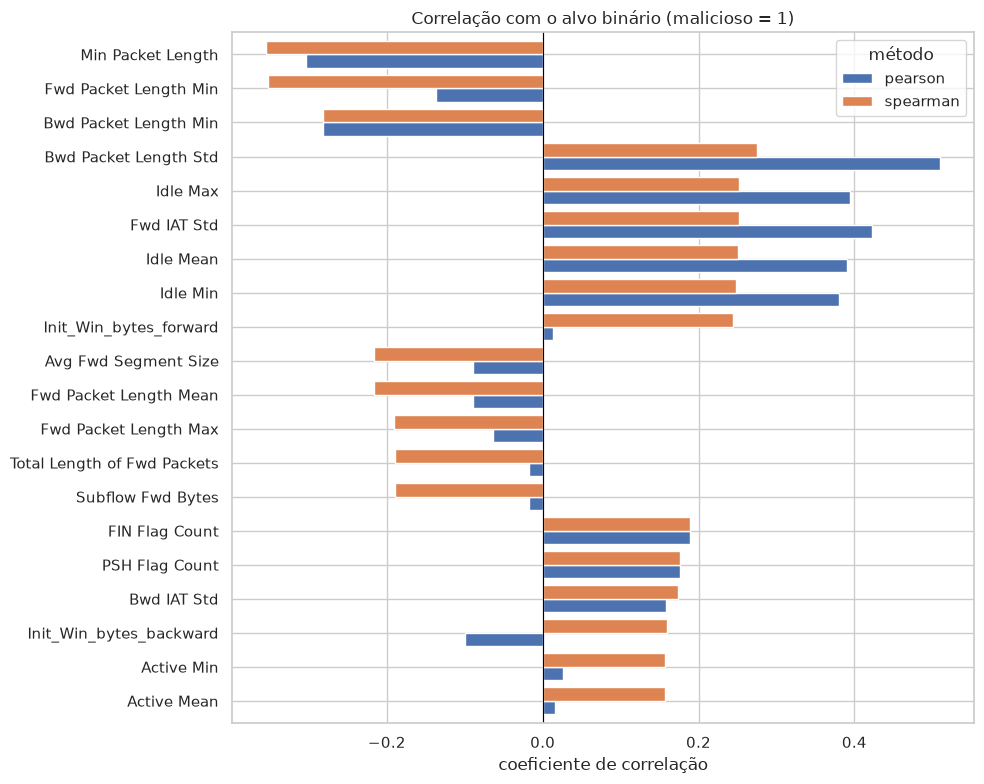

In [20]:
# top 20 por |spearman|, com o pearson ao lado pra mostrar onde divergem
top = corr_alvo.head(20).iloc[::-1]

ax = top.plot.barh(figsize=(10, 8), width=0.8)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Correlação com o alvo binário (malicioso = 1)")
ax.set_xlabel("coeficiente de correlação")
ax.legend(title="método")
plt.tight_layout()
plt.show()

Dos 69 atributos ranqueados, nenhum passa de |ρ| ≈ 0,36, ou seja, o sinal linear ou monotônico de cada atributo isolado é fraco. Os primeiros por Spearman são `Min Packet Length` (ρ = -0,36) e `Fwd Packet Length Min` (ρ = -0,35), ambos negativos: um tamanho mínimo de pacote maior se associa a tráfego benigno.

Pearson e Spearman divergem bastante, o que é esperado com caudas pesadas. `Bwd Packet Length Std` tem r = 0,51 e ρ = 0,28, e `Bwd Packet Length Max` passa de r = 0,49 para ρ = 0,09, pois o Pearson é influenciado por poucos valores extremos. Por isso, o ranking por Spearman é o mais confiável aqui. Também ocorre o caso contrário: `Init_Win_bytes_forward` tem r = 0,01 e ρ = 0,24, uma relação monotônica mas não linear. A seção de padrão de ocorrência, mais adiante, aponta a provável causa, o valor -1 presente em 35% dos fluxos e quase exclusivo do tráfego benigno.

O ranking repete colunas redundantes já encontradas (`Avg Fwd Segment Size` é idêntica a `Fwd Packet Length Mean`, e `Subflow Fwd Bytes` é quase idêntica a `Total Length of Fwd Packets`, com 1 linha de diferença), que não trazem informação nova. Como nenhum atributo separa as classes sozinho, é provável que a separação venha de combinações de atributos, o que favorece modelos não lineares. Além disso, o alvo binário agrupa ataques de natureza distinta, o que pode diminuir a correlação de atributos específicos de cada tipo.

### Ranking de Separabilidade

Para medir o quanto cada atributo isolado separa fluxos benignos de maliciosos, foi utilizado o AUC, que é a probabilidade de um fluxo malicioso ter um valor maior que o de um fluxo benigno. A separabilidade foi definida como `max(AUC, 1 - AUC)`, sendo 0,5 nenhuma separação e 1,0 separação perfeita. Um AUC abaixo de 0,5 indica valores menores no tráfego malicioso.

O AUC foi escolhido no lugar da diferença de medianas normalizada pelo IQR porque 24 das 77 colunas têm IQR = 0, e vários dos melhores atributos têm mediana 0 nos dois grupos, o que impediria essa comparação.

In [21]:
# x e y_malicioso vem da celula de correlacao com o alvo (inf ja virou nan)
from sklearn.metrics import roc_auc_score

colunas = X.columns.drop("Destination Port")  # nominal, auc nao faz sentido
y = y_malicioso.to_numpy().astype(bool)

aucs = {}
for col in colunas:
    x = X[col].to_numpy(dtype="float64")
    ok = ~np.isnan(x)
    if np.nanmin(x) == np.nanmax(x):  # constante, auc indefinido
        continue
    aucs[col] = roc_auc_score(y[ok], x[ok])

ranking = pd.DataFrame({"auc": pd.Series(aucs)})
ranking["separabilidade"] = np.maximum(ranking["auc"], 1 - ranking["auc"])
ranking["mediana_benigno"] = X.loc[~y, ranking.index].median()
ranking["mediana_malicioso"] = X.loc[y, ranking.index].median()
ranking = ranking.sort_values("separabilidade", ascending=False)

print("atributos no ranking:", len(ranking))
print("separabilidade > 0.7:", int((ranking["separabilidade"] > 0.7).sum()))
print("separabilidade maxima:", round(ranking["separabilidade"].max(), 3))

ranking.head(15)

atributos no ranking: 69
separabilidade > 0.7: 2
separabilidade maxima: 0.743


,auc,separabilidade,mediana_benigno,mediana_malicioso
Min Packet Length,0.26,0.74,6.00,0.00
Fwd Packet Length Min,0.26,0.74,6.00,0.00
Bwd Packet Length Min,0.31,0.69,6.00,0.00
Init_Win_bytes_forward,0.67,0.67,118.00,274.00
Bwd Packet Length Std,0.66,0.66,0.00,0.00
Fwd IAT Std,0.66,0.66,0.00,"1,825.75"
Avg Fwd Segment Size,0.34,0.66,37.00,6.00
Fwd Packet Length Mean,0.34,0.66,37.00,6.00
Fwd Packet Length Max,0.36,0.64,40.00,6.00
Total Length of Fwd Packets,0.36,0.64,66.00,24.00


#### Boxplots dos atributos mais separáveis

Foram selecionados os 6 melhores atributos do ranking, ignorando os redundantes (|ρ| de Spearman acima de 0,9 com um atributo já escolhido, medido em uma amostra). Os outliers foram ocultados para não esmagar as caixas.

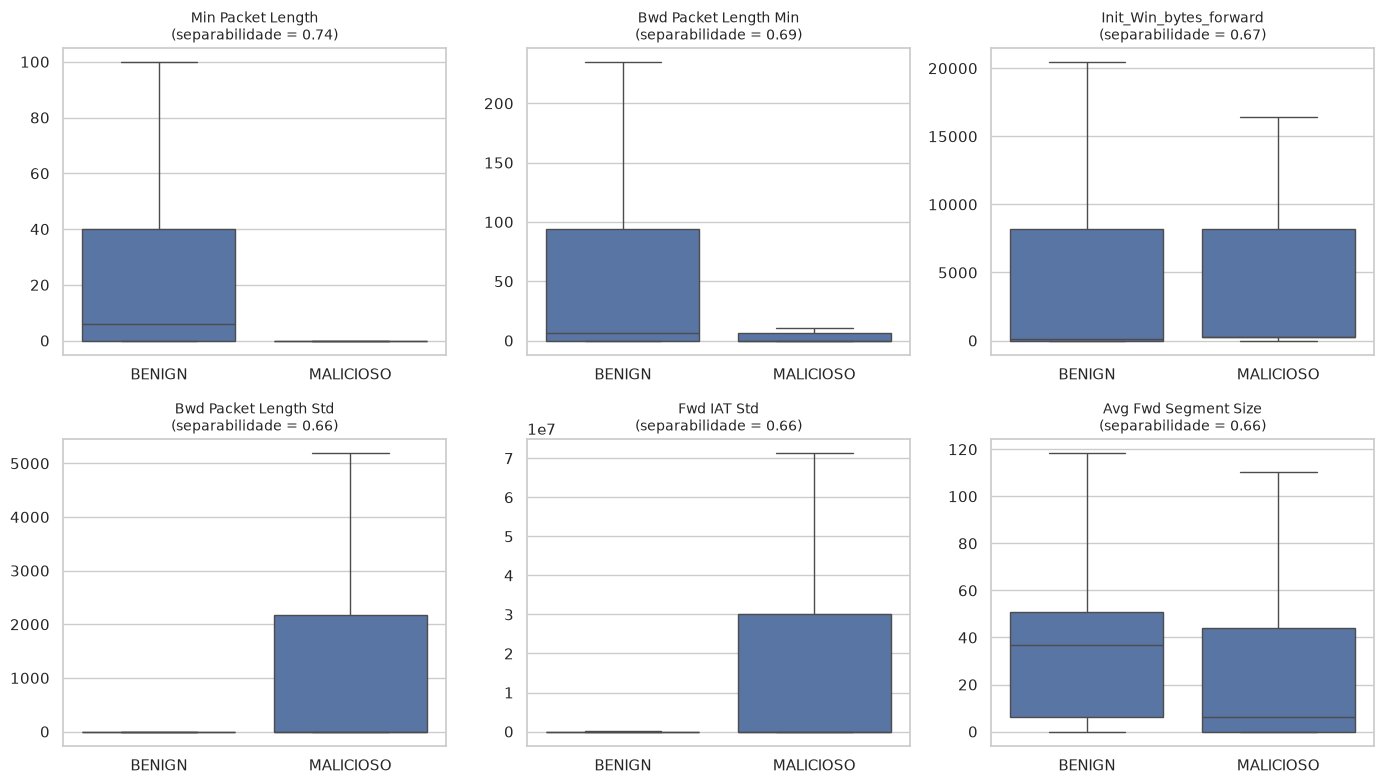

In [22]:
# pula quem e redundante (|spearman| > 0.9) com um atributo ja escolhido
amostra = X.sample(300_000, random_state=42)  # amostra so pra essa checagem
sp = amostra[ranking.index[:25]].corr(method="spearman").abs()

escolhidos = []
for col in ranking.index[:25]:
    if all(sp.loc[col, e] < 0.9 for e in escolhidos):
        escolhidos.append(col)
    if len(escolhidos) == 6:
        break

grupo = np.where(y, "MALICIOSO", "BENIGN")

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, col in zip(axes.ravel(), escolhidos):
    sns.boxplot(x=grupo, y=X[col], order=["BENIGN", "MALICIOSO"], showfliers=False, ax=ax)
    ax.set_title(f"{col}\n(separabilidade = {ranking.loc[col, 'separabilidade']:.2f})", fontsize=10)
    ax.set_xlabel("")
    ax.set_ylabel("")
plt.tight_layout()
plt.show()

Nenhum atributo isolado separa bem as classes. Dos 69 avaliados, apenas 2 passam de 0,7 de separabilidade e o máximo é 0,74 (`Min Packet Length` e `Fwd Packet Length Min`). Nos dois, a mediana é 6 no tráfego benigno e 0 no malicioso, ou seja, fluxos maliciosos tendem a ter pacotes de tamanho mínimo menor.

O ranking é consistente com a correlação com o alvo, pois os mesmos atributos aparecem no topo (tamanhos mínimos de pacote, `Bwd Packet Length Std` e os atributos `Idle *`), e os dois métodos são independentes. A separabilidade também mostra casos que as medianas não mostram: `Bwd Packet Length Std` tem mediana 0 nos dois grupos, mas no tráfego malicioso o terceiro quartil passa de 2000, enquanto no benigno a caixa fica próxima de zero. Já `Init_Win_bytes_forward` tem caixas parecidas no gráfico, e a separabilidade de 0,67 vem da região baixa da distribuição (medianas de 118 e 274), onde está o valor -1, quase exclusivo do tráfego benigno (ver o padrão de ocorrência adiante).

Há redundância no topo do ranking: `Min Packet Length` e `Fwd Packet Length Min` têm o mesmo AUC, assim como `Idle Max`, `Idle Mean` e `Idle Min`, e `Avg Fwd Segment Size` repete `Fwd Packet Length Mean` (colunas idênticas). Com separabilidade máxima de 0,74, nenhum atributo sozinho é suficiente, e o ganho deve vir de combinações, o que favorece modelos não lineares e uma seleção de atributos que considere a redundância. Além disso, o alvo binário agrupa vários tipos de ataque, então atributos específicos de um tipo podem ficar subestimados nesta métrica.

### Outliers (regra do IQR)

Foi aplicada a regra de Tukey (valores fora do intervalo de `Q1 - 1,5·IQR` a `Q3 + 1,5·IQR`) aos atributos numéricos que não são flags binárias, constantes nem a porta de destino (nominal), com o `inf` tratado como `NaN` apenas neste cálculo. Os atributos com IQR = 0 ficaram fora, porque a regra não se aplica a eles. Além do percentual por atributo, foi medida a parcela desses outliers que pertence a fluxos maliciosos, pois se os valores extremos forem justamente os ataques, removê-los eliminaria a classe positiva.

In [23]:
# numericas vem da celula de correlacao; tira flags/constantes (<= 2 valores) e a porta (nominal)
cols_out = [c for c in numericas if df[c].nunique() > 2 and c != "Destination Port"]
Xo = df[cols_out].replace([np.inf, -np.inf], np.nan)

q1, q3 = Xo.quantile(0.25), Xo.quantile(0.75)
iqr = q3 - q1

# iqr = 0: qualquer valor diferente da mediana viraria outlier, regra nao se aplica
sem_iqr = iqr[iqr == 0].index.tolist()
aplicaveis = iqr[iqr > 0].index

limite_inf = q1[aplicaveis] - 1.5 * iqr[aplicaveis]
limite_sup = q3[aplicaveis] + 1.5 * iqr[aplicaveis]
eh_outlier = (Xo[aplicaveis] < limite_inf) | (Xo[aplicaveis] > limite_sup)

y_mal = (df["Label"] != "BENIGN").to_numpy()
outliers_por_col = pd.DataFrame({
    "pct_outlier": eh_outlier.mean() * 100,
    "n_outlier": eh_outlier.sum(),
    "pct_malicioso_nos_outliers": [
        y_mal[eh_outlier[c].to_numpy()].mean() * 100 if eh_outlier[c].any() else np.nan
        for c in aplicaveis
    ],
}).sort_values("pct_outlier", ascending=False)

print("atributos avaliados:", len(cols_out), "| com iqr = 0 (fora):", sem_iqr)
print(f"% de outliers por atributo: mediana {outliers_por_col['pct_outlier'].median():.1f}, "
      f"maximo {outliers_por_col['pct_outlier'].max():.1f}")
print("atributos com > 10% de outliers:", int((outliers_por_col["pct_outlier"] > 10).sum()),
      "| com > 20%:", int((outliers_por_col["pct_outlier"] > 20).sum()))
print(f"% malicioso na base: {y_mal.mean() * 100:.1f} | entre os outliers (mediana dos atributos): "
      f"{outliers_por_col['pct_malicioso_nos_outliers'].median():.1f}")

outliers_por_col.head(12)

atributos avaliados: 59 | com iqr = 0 (fora): ['Active Mean', 'Active Std', 'Active Max', 'Active Min', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']
% de outliers por atributo: mediana 16.7, maximo 23.7
atributos com > 10% de outliers: 43 | com > 20%: 16
% malicioso na base: 19.7 | entre os outliers (mediana dos atributos): 25.1


,pct_outlier,n_outlier,pct_malicioso_nos_outliers
Fwd IAT Mean,23.73,671833,34.47
Fwd IAT Max,23.54,666292,34.15
Fwd IAT Total,23.52,665766,34.05
Fwd Packet Length Max,23.46,664214,25.71
Fwd Packet Length Std,23.46,663959,25.63
Fwd IAT Std,23.33,660519,35.57
Packet Length Variance,23.12,654542,37.37
Bwd Packet Length Std,23.11,654269,37.79
Bwd Packet Length Max,22.51,637112,38.79
Max Packet Length,22.04,623901,39.17


In [24]:
# em quantos atributos cada fluxo e outlier
k = eh_outlier.sum(axis=1).to_numpy()

faixas = {"nenhum atributo": k == 0, ">= 1 atributo": k >= 1, ">= 5 atributos": k >= 5,
          ">= 10 atributos": k >= 10, ">= 20 atributos": k >= 20}
tabela_k = pd.DataFrame({
    "fluxos": {nome: int(m.sum()) for nome, m in faixas.items()},
    "pct_da_base": {nome: m.mean() * 100 for nome, m in faixas.items()},
    "pct_malicioso": {nome: y_mal[m].mean() * 100 for nome, m in faixas.items()},
})

# custo de "limpar" outliers: quantos fluxos maliciosos iriam embora
perdidos = y_mal[k >= 1].sum() / y_mal.sum()
print(f"remover todo fluxo com algum atributo outlier descartaria {(k >= 1).mean():.1%} da base "
      f"e {perdidos:.1%} dos fluxos maliciosos")

tabela_k

remover todo fluxo com algum atributo outlier descartaria 84.8% da base e 93.1% dos fluxos maliciosos


,fluxos,pct_da_base,pct_malicioso
nenhum atributo,431149,15.23,8.90
>= 1 atributo,2399594,84.77,21.64
>= 5 atributos,1001923,35.39,30.82
>= 10 atributos,821975,29.04,32.15
>= 20 atributos,527237,18.63,33.85


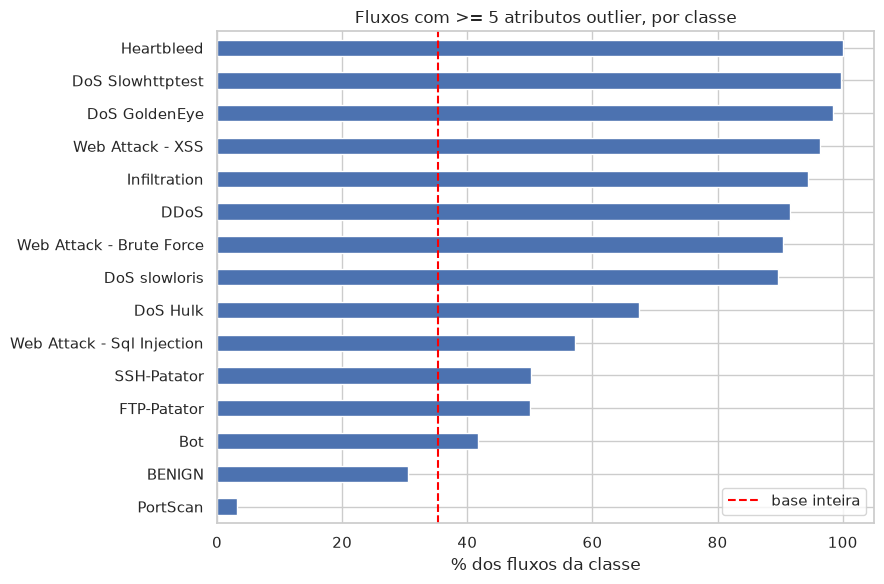

In [25]:
# intensidade de outliers por classe: % de fluxos com >= 5 atributos outlier
por_classe = (
    pd.Series(k >= 5, index=df.index)
    .groupby(df["Label"], observed=True).mean()
    .mul(100).sort_values()
)

ax = por_classe.plot.barh(figsize=(9, 6))
ax.axvline((k >= 5).mean() * 100, color="red", linestyle="--", label="base inteira")
ax.set_title("Fluxos com >= 5 atributos outlier, por classe")
ax.set_xlabel("% dos fluxos da classe")
ax.set_ylabel("")
ax.legend()
plt.tight_layout()
plt.show()

A regra do IQR marca uma parcela grande dos dados: a mediana é de 16,7% de outliers por atributo (máximo de 23,7%) e 43 dos 51 atributos aplicáveis passam de 10%. Como as distribuições são assimétricas e de cauda longa, a regra de Tukey, pensada para dados aproximadamente simétricos, trata como anomalia o comportamento normal da base. Os 8 atributos `Active *` e `Idle *` têm IQR = 0 e ficaram fora da análise.

Remover os outliers eliminaria a maior parte da classe positiva: 84,8% dos fluxos têm ao menos um atributo outlier, e descartá-los retiraria 93,1% dos fluxos maliciosos. A proporção de fluxos maliciosos cresce com o número de atributos extremos (8,9% sem nenhum, 21,6% com ao menos 1, 30,8% com 5 ou mais e 33,9% com 20 ou mais), e 7 das 14 classes de ataque têm 90% ou mais dos fluxos com 5 ou mais atributos outlier (`DoS slowloris` fica em 89,6%), contra 30,5% no tráfego benigno. Por outro lado, outlier não é sinônimo de ataque: mesmo com 20 ou mais atributos extremos, cerca de 66% dos fluxos são benignos, e `PortScan` apresenta o comportamento contrário, com apenas 3,1% dos fluxos nessa condição.

Portanto, a hipótese é não remover os outliers e tratar a cauda com técnicas adequadas a esse tipo de distribuição (transformação logarítmica, escalonamento por quantis). O número de atributos outlier por fluxo carrega informação, mas, se for usado como *feature*, os limites do IQR precisam ser calculados apenas no conjunto de treino.

### Padrão de Ocorrência dos Problemas de Qualidade

Para cada problema já contado (`NaN`, `inf` e valores negativos), foi medido onde ele se concentra, por classe e por arquivo de origem, e se o padrão difere da base (19,7% de fluxos maliciosos). Para os valores indefinidos das taxas, também foi testada a hipótese de que vêm da divisão por duração de fluxo igual a zero.

In [26]:
# mascaras dos problemas de qualidade ja identificados
fb = df["Flow Bytes/s"].astype("float64")
fp = df["Flow Packets/s"].astype("float64")

problemas = {
    "NaN em Flow Bytes/s": fb.isna(),
    "inf em Flow Bytes/s": np.isinf(fb),
    "inf em Flow Packets/s": np.isinf(fp),
    "Flow Duration < 0": df["Flow Duration"] < 0,
    "Fwd Header Length < 0": df["Fwd Header Length"] < 0,
    "Init_Win_bytes_forward = -1": df["Init_Win_bytes_forward"] == -1,
    "Init_Win_bytes_backward = -1": df["Init_Win_bytes_backward"] == -1,
}

linhas = []
for nome, m in problemas.items():
    afetados = df[m]
    linhas.append({
        "problema": nome,
        "linhas": int(m.sum()),
        "pct_da_base": m.mean() * 100,
        "pct_malicioso": (afetados["Label"] != "BENIGN").mean() * 100,
        "classe_mais_comum": afetados["Label"].value_counts().idxmax(),
        "arquivo_mais_comum": afetados["source_file"].value_counts().idxmax().replace(".pcap_ISCX", ""),
    })

print(f"referencia: {(df['Label'] != 'BENIGN').mean() * 100:.1f}% da base e maliciosa")
pd.DataFrame(linhas).set_index("problema")

referencia: 19.7% da base e maliciosa


,linhas,pct_da_base,pct_malicioso,classe_mais_comum,arquivo_mais_comum
problema,,,,,
NaN em Flow Bytes/s,1358,0.05,69.88,DoS Hulk,Wednesday-workingHours
inf em Flow Bytes/s,1509,0.05,9.34,BENIGN,Monday-WorkingHours
inf em Flow Packets/s,2867,0.10,38.02,BENIGN,Wednesday-workingHours
Flow Duration < 0,115,0.00,0.00,BENIGN,Friday-WorkingHours-Afternoon-PortScan
Fwd Header Length < 0,35,0.00,0.00,BENIGN,Monday-WorkingHours
Init_Win_bytes_forward = -1,1001189,35.37,0.00,BENIGN,Monday-WorkingHours
Init_Win_bytes_backward = -1,1441552,50.92,8.50,BENIGN,Wednesday-workingHours


In [27]:
# nan e inf das taxas sao divisao por duracao zero?
dur = df["Flow Duration"]
bytes_total = df["Total Length of Fwd Packets"].astype("int64") + df["Total Length of Bwd Packets"]

for nome in ["NaN em Flow Bytes/s", "inf em Flow Bytes/s", "inf em Flow Packets/s"]:
    m = problemas[nome]
    print(f"{nome:<24} duracao == 0 em {(dur[m] == 0).mean():.0%} dos casos | "
          f"bytes totais == 0 em {(bytes_total[m] == 0).mean():.0%}")

NaN em Flow Bytes/s      duracao == 0 em 100% dos casos | bytes totais == 0 em 100%
inf em Flow Bytes/s      duracao == 0 em 100% dos casos | bytes totais == 0 em 0%
inf em Flow Packets/s    duracao == 0 em 100% dos casos | bytes totais == 0 em 47%


Os problemas de qualidade não ocorrem de forma aleatória. Os `NaN` e `inf` das taxas vêm todos de fluxos com duração zero: `Flow Bytes/s` fica `NaN` quando a duração e os bytes são zero (0/0, em 100% dos casos) e `inf` quando há bytes em uma duração zero, e `Flow Packets/s` fica `inf` pela mesma divisão. Portanto, são problemas da extração das *features* e não falhas dispersas. Eles também não se distribuem como a base: 69,9% dos fluxos com `NaN` em `Flow Bytes/s` são maliciosos (949 dos 1.358 são `DoS Hulk`, e 1.008 vêm do arquivo de quarta-feira), contra 19,7% na base, enquanto o `inf` em `Flow Bytes/s` é majoritariamente benigno (apenas 9,3% de fluxos maliciosos). Como a duração zero aparece em tipos de tráfego distintos, a imputação desses valores deve ser feita dentro do pipeline, e a própria duração zero é uma informação relevante.

Os valores negativos fora de domínio são raros e aparecem apenas no tráfego benigno: `Flow Duration` < 0 (115 fluxos) e `Fwd Header Length` < 0 (35 fluxos) não têm nenhum fluxo malicioso e estão espalhados por arquivos diferentes, o que é compatível com erros de medição. Tratá-los tem custo baixo, já que nenhum ataque é perdido.

O valor -1 em `Init_Win_bytes_*` é um caso diferente: afeta 35,4% (*forward*) e 50,9% (*backward*) da base e não parece ser um erro, e sim um valor que indica ausência de informação. Em `Init_Win_bytes_forward`, 1.001.182 dos 1.001.189 fluxos com -1 são benignos (apenas 7 são maliciosos). Por isso, esse valor não deve ser corrigido nem imputado como ruído, e sim preservado ou sinalizado por uma variável indicadora, já que é um dos poucos marcadores quase exclusivos do tráfego benigno. Isso provavelmente explica por que `Init_Win_bytes_forward` aparece no ranking de Spearman (ρ = 0,24) mas quase não aparece no de Pearson (r = 0,01).